In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve

Calculated Submersion Time (t_s): 64.49999999999999 seconds


<>:125: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
<>:125: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
/tmp/ipykernel_21398/3098189724.py:125: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
  plt.ylabel('Surface Elevation $\eta$ (meters)')
/tmp/ipykernel_21398/3098189724.py:34: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  t_s = fsolve(time_submerge, 2.0)[0] # Initial guess is of 2s!


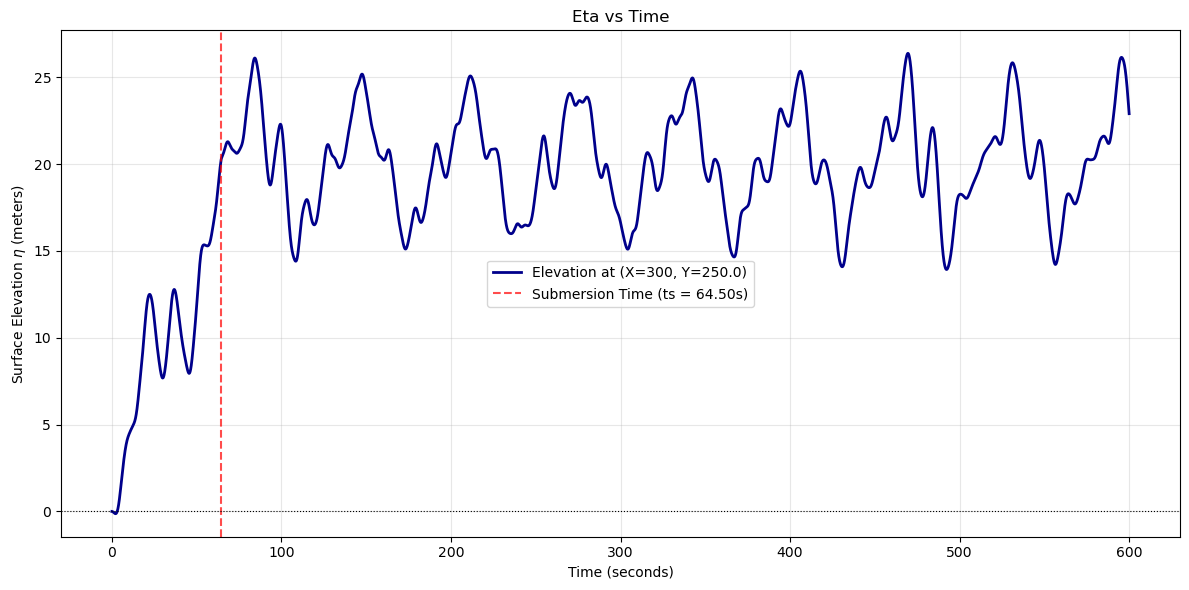

In [4]:
# Dimensions of rectangular reservoir
L = 1000 # Length of the reservoir
W = 500 # Width of the reservoir
h0 = 100 # Constant depth of water

# Dimensions of the parcel of water added from outside
l = 200 # Length of the parcel
w = 200 # Width of the parcel
h = 250 # Height of the parcel

# Coordinates of the centre of the place where the parcel hits
x0 = 100
y0 = 250

# Number of modes we want to sum up
M_max = 10
N_max = 10

# Some other constants
g = 9.81 # Gravitational acceleration
v_term = 4 # terminal velocity of the parcel
tau = 2.0 # Time constant for the parcel's velocity decay (s)

# Define the probe location (where the virtual gauge is)
x_probe = 300 
y_probe = 250.0  

# Define the time array (0 to 60 seconds, 1000 steps)
t_array = np.linspace(0, 600.0, 10000)

def time_submerge(t):
    return v_term * (t - tau * (1 - np.exp(-t / tau))) - h

t_s = fsolve(time_submerge, 2.0)[0] # Initial guess is of 2s!
print(f"Calculated Submersion Time (t_s): {t_s} seconds")

# Wave speed
c = np.sqrt(g * h0)

def get_omega(m, n):
    return c * np.sqrt((m * np.pi / L)**2 + (n * np.pi / W)**2)

def get_fmn(m, n):
    
    """
    Calculates the spatial Fourier coefficient for the landslide footprint
    """

    if m == 0 and n == 0:
        return (l * w) / (L * W)
    elif m > 0 and n == 0:
        return (4 * w) / (m * np.pi * W) * np.cos(m * np.pi * x0 / L) * np.sin(m * np.pi * l / (2 * L))
    elif m == 0 and n > 0:
        return (4 * l) / (n * np.pi * L) * np.cos(n * np.pi * y0 / W) * np.sin(n * np.pi * w / (2 * W))
    else:
        return (16 / (np.pi**2 * m * n)) * np.cos(m * np.pi * x0 / L) * np.cos(n * np.pi * y0 / W) * \
               np.sin(m * np.pi * l / (2 * L)) * np.sin(n * np.pi * w / (2 * W))
    

def get_a00_array(t_arr):
    """
    Calculates the uniform mean sea level rise (Zero-Mode) across time
    """

    # Phase 1: Water level rises as the block enters
    phase1 = (l * w / (L * W)) * v_term * (t_arr - tau * (1 - np.exp(-t_arr / tau)))
    
    # Phase 2: Water level locks in permanently after submersion
    phase2 = (l * w / (L * W)) * v_term * (t_s - tau * (1 - np.exp(-t_s / tau)))
    
    return np.where(t_arr <= t_s, phase1, phase2)

def get_amn_array(m, n, t_arr):
    """
    Calculates the time-dependent amplitude trajectory for mode (m, n)
    """

    if m == 0 and n == 0:
        return get_a00_array(t_arr)
        
    omega = get_omega(m, n)
    fmn = get_fmn(m, n)
    
    Amn = (fmn * v_term * tau) / (1 + (omega * tau)**2)
    
    # Evaluate Phase 1 equation (t <= t_s)
    phase1 = Amn * (np.exp(-t_arr/tau) - np.cos(omega * t_arr) + (1/(omega * tau)) * np.sin(omega * t_arr))
    
    # Evaluate Phase 2 equation (t > t_s)
    p2_decay = np.exp(-t_s/tau) * (np.cos(omega * (t_arr - t_s)) - (1/(omega * tau)) * np.sin(omega * (t_arr - t_s)))
    p2_oscillatory = -np.cos(omega * t_arr) + (1/(omega * tau)) * np.sin(omega * t_arr)
    phase2 = Amn * (p2_decay + p2_oscillatory)
    
    # Merge the two phases at the submersion boundary
    return np.where(t_arr <= t_s, phase1, phase2)


# Initialize an array of zeros to hold the final water surface elevation
eta_time_series = np.zeros_like(t_array)

# Nested loop to sum up all the Fourier modes
for m in range(M_max + 1):
    for n in range(N_max + 1):
        
        # Get the time-varying amplitude array for this specific mode
        a_mn_t = get_amn_array(m, n, t_array)
        
        # Calculate the spatial footprint factor strictly at the probe's location
        spatial_factor = np.cos(m * np.pi * x_probe / L) * np.cos(n * np.pi * y_probe / W)
        
        # Multiply and add to the total surface elevation
        eta_time_series += a_mn_t * spatial_factor

plt.figure(figsize=(12, 6))

# Plot the main wave time-series
plt.plot(t_array, eta_time_series, color='darkblue', linewidth=2, label=f'Elevation at (X={x_probe}, Y={y_probe})')

# Mark the exact moment the block finishes entering the water
plt.axvline(x=t_s, color='red', linestyle='--', alpha=0.7, label=f'Submersion Time (ts = {t_s:.2f}s)')

# Formatting the graph
plt.title('Eta vs Time')
plt.xlabel('Time (seconds)')
plt.ylabel('Surface Elevation $\eta$ (meters)')
plt.axhline(y=0, color='black', linewidth=0.8, linestyle=':') # Zero-line (undisturbed water)
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

In [5]:
grid_res = 200
x_arr = np.linspace(0, L, grid_res)
y_arr = np.linspace(0, W, grid_res)
X, Y = np.meshgrid(x_arr, y_arr)

# Choose the snapshot time 
t_snapshot = 600.0

# Calculate the 3D surface over the entire lake at t_snapshot
eta_surface = np.zeros_like(X)

for m in range(M_max + 1):
    for n in range(N_max + 1):
        a_mn = get_amn_array(m, n, t_snapshot)
        
        # Calculate spatial matrix and add to total surface
        spatial_matrix = np.cos(m * np.pi * X / L) * np.cos(n * np.pi * Y / W)
        eta_surface += a_mn * spatial_matrix



# Theoretical volume
volume_added = l * w * h

# Double Integration using the Trapezoidal Rule
integral_along_y = np.trapezoid(eta_surface, y_arr, axis=0)
delta_V_numeric = np.trapezoid(integral_along_y, x_arr, axis=0)

error_pct = abs(volume_added - delta_V_numeric) / volume_added * 100

print(f"Volume of landslide dropped (l*w*h): {volume_added} m^3")
print(f"Extra volume measured in lake: {delta_V_numeric} m^3")
print(f"Grid Integration Error: {error_pct}%")

Volume of landslide dropped (l*w*h): 10000000 m^3
Extra volume measured in lake: 10000000.0 m^3
Grid Integration Error: 0.0%


In [31]:
L * W *h0

50000000